## Images as Numerical Data

### Import resources

Befor starting with images, we need to import some Python packages. These packages allow us to use advanced functionality with ease, such as loading and displaying images. Feel free to check the packages website for more detail.

In [3]:
from __future__ import print_function
# numpy is a package for fast scientific computing. See https://numpy.org for more details. 
import numpy as np
# matplotlib.pyplot is a package for plotting data (incl. images.) See https://matplotlib.org for more details. 
import matplotlib.pyplot as plt
# cv2 is a computer vision library. See https://opencv.org
import cv2  # computer vision library

# Utility functions - only used for GUI features
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

%matplotlib inline

### Read in and display the image

Let us read and display our first image from the computers drive. 

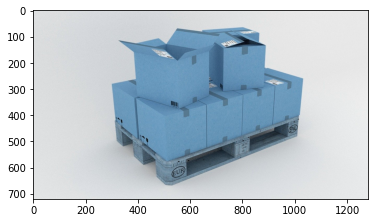

In [4]:
# Read in the image. Feel free to change the path
image = cv2.imread('images/pallet.jpg')

plt.imshow(image)

Before we start with Color Images, lets have a look at grayscale first:

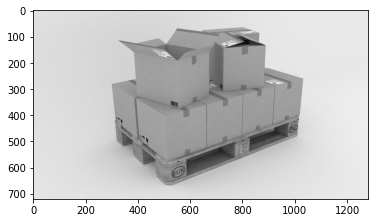

In [5]:
# Change from RGB to Grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray_image, cmap='gray')

A grayscale image can be described as a matrix `r * c`, where each entry corresponds to the intensity value of a pixel.

Using OpenCV we can now have a look at this information using the `.shape` property of our `gray_image` instance: 

In [6]:
print('Image dimensions:', gray_image.shape)
print('Rows of Pixels:', gray_image.shape[0])
print('Columns of Pixels:', gray_image.shape[1])

Image dimensions: (720, 1280)
Rows of Pixels: 720
Columns of Pixels: 1280


Using the `.max()` and `.min()` member functions of our `gray_image` allows us to check for the minimum and maximum intensity values being used in our image.

In [7]:
# We can also check for the minimum and maximum pixel value in an image
print('Max: ', gray_image.max())
print('Min: ', gray_image.min())

Max:  255
Min:  1


We can not only print out image metadata, such as the amount of rows or columns, but also analyse pixel values by accessing an entry in the matrix by specifing row and column:

In [8]:
# In order to get the pixel value at row 250 and column 300, we access the value in the image like so: 
col = 500 
row = 600

print(gray_image[row,col])

151


Using this accessing mechanism, we can also (over)write intensity values of a certain pixel:

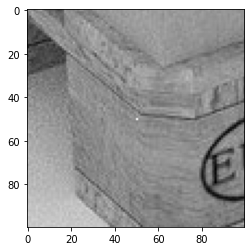

In [9]:
# We can change pixel values by assign a value to a pixel
# 0: black, 255: white
gray_image[row,col] = 255

plt.imshow(gray_image[row-50:row+50, col-50:col+50], cmap='gray')



Similar to accessing a single pixel, we can write new intensity values to patches of pixels by specifiying a single patch using the `:` operator.

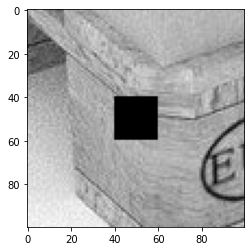

In [10]:
# We can change pixel values by assign a value to a pixel
row_start = row - 10 
row_end = row + 10
col_start = col - 10
col_end = col + 10
gray_image[row_start:row_end,col_start:col_end] = 0

plt.imshow(gray_image[row-50:row+50, col-50:col+50], cmap='gray')

So far we have read out pixel values and changed them. 
Furthermore we can use arithmetic operators on a pixel to add, subtract, multiply or divide a pixel value by a given variable.

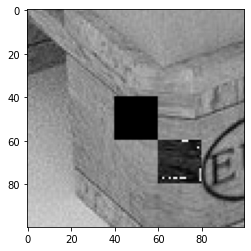

In [11]:
offset = 20

patch = gray_image[row_start+offset:row_end+offset,col_start+offset:col_end+offset]
gray_image[row_start+offset:row_end+offset,col_start+offset:col_end+offset] = patch * 2

plt.imshow(gray_image[row-50:row+50, col-50:col+50], cmap='gray')

Using this knowledge, we can already program our first digital image processing function. Changing the brightness of an image, for example corresponds to multiplying each pixel value by a multiplier. We specify the whole image as a patch using the `:`-operator again. In contrast to our usage before, we do not specify the start and end of our patch. Python then automatically assumes we want to address the whole image. 

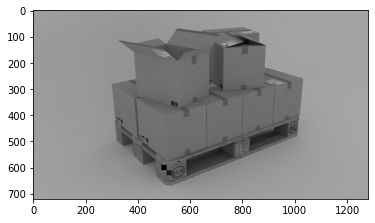

In [12]:
def change_brightness(x):
    scaled_im = gray_image[:,:] * x
    plt.imshow(scaled_im, vmin=0, vmax=255, cmap='gray')               

# This function helps to interactively visualise our image. 
interact(change_brightness, x=(0.1, 1.5, 0.1));

... now let's try to apply this knowledge:

# Excercise 1

You have learned how the computer interprets an image. Let's manually draw a tiny image of a smilie face.

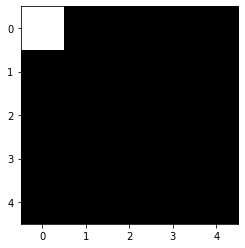

In [13]:
# Create a 5x5 image using just grayscale, numerical values

# Step 1: Create a numpy array. This 2d array corresponds to the pixel values of the image. 
tiny_image = np.array([[255, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0],
                      [0, 0, 0, 0, 0],
                      [0, 0,0,0 ,0 ]])

# To show the pixel grid, use imshow
plt.imshow(tiny_image, cmap='gray')

## TODO: See if you can draw a tiny smilie face!

# Exercise 2

What other member functions and properties does the image class in OpenCV provide? Try using these functions and properties yourself and visualise their outcome.

*Hint:* In order to not having to remember member functions and properties of object instances or write out variables, Jupyter features auto-completion functionality by using `tab`.

*Hint 2:* You can get information about a property, function or class using `shift + tab`

In [14]:
gray_image.T

array([[230, 214, 231, ..., 226, 229, 229],
       [224, 224, 229, ..., 226, 233, 237],
       [220, 232, 226, ..., 226, 234, 237],
       ...,
       [235, 235, 235, ..., 236, 235, 232],
       [232, 231, 230, ..., 236, 236, 231],
       [236, 235, 233, ..., 237, 238, 233]], dtype=uint8)

# Segmentation

Let us now create a function to segment objects with same intensity. Segmentation is a basic image processing function that is included in a magnitude of software such as Microsoft PowerPoint, Photoshop, etc.

In segmentation we aim to create a "binary" mask that seperates pixels within a certain intensity range from pixels outside of that range. For this we first define an upper and lower limit intensity value. We then test if a pixel value lies within the specified intensity range. OpenCV provides the `cv2.inRange()` function. We store the result in a so-called mask. If the value lies within the specified intensity range, the value "255" is set. If the value is outside the considered range, the value "0" is set. Using this mask we can than segment out areas outside the specified intensity range.

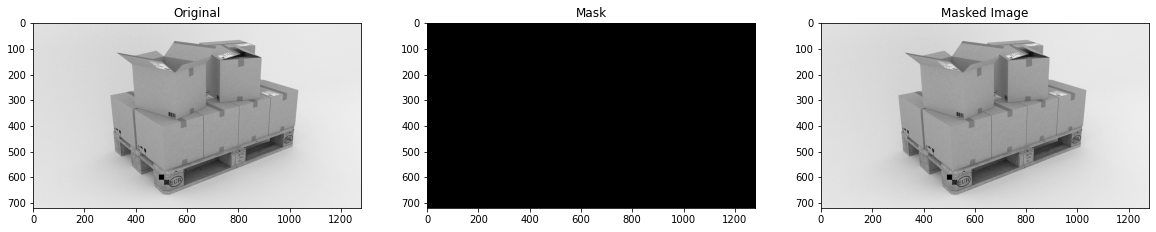

In [15]:
def intensity_segmentation(min=0, max=255):
    # Define the mask
    mask = cv2.inRange(gray_image, min, max)

    # Create a copy of the image
    masked_image = np.copy(gray_image)
    # Mask the image. If the masks value at a given matrix index is 0, overwrite the images value.
    masked_image[mask==0] = 0

    # Vizualize the mask
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))

    ax1.set_title('Original')
    ax1.imshow(gray_image, cmap='gray')

    ax2.set_title('Mask')
    ax2.imshow(mask, cmap='gray')

    ax3.set_title('Masked Image')
    ax3.imshow(masked_image, cmap='gray')
    
interact(intensity_segmentation, 
         min=(0, 255,1), max=(0, 255,1));


# Exercise 3:

Find the min and max values for segmenting out the pallet including parcels.